# Pressure robustness convergence plot

This notebook recreates the convergence plot and saves both a PNG and a PDF.


Saved: stokes_pressure_robustness_convergence_grouped_colors.png
Saved: stokes_pressure_robustness_convergence_grouped_colors.pdf


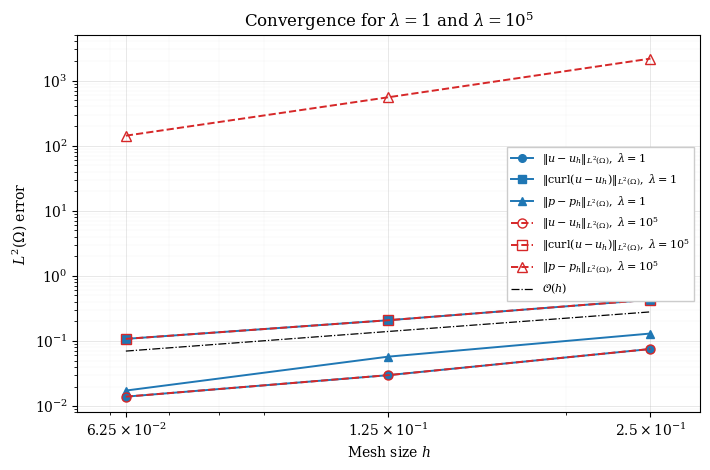

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter, NullFormatter

h_raw = np.array([0.25, 0.125, 0.0625])
order = np.argsort(h_raw)
h = h_raw[order]

series = [
    (r"$\|u-u_h\|_{L^2(\Omega)},\ \lambda=1$",
     np.array([0.0753365, 0.0298612, 0.013965])[order], "o", "-", "tab:blue"),
    (r"$\|\operatorname{curl}(u-u_h)\|_{L^2(\Omega)},\ \lambda=1$",
     np.array([0.430091, 0.208413, 0.107828])[order], "s", "-", "tab:blue"),
    (r"$\|p-p_h\|_{L^2(\Omega)},\ \lambda=1$",
     np.array([0.13019, 0.0574617, 0.0173265])[order], "^", "-", "tab:blue"),
    (r"$\|u-u_h\|_{L^2(\Omega)},\ \lambda=10^5$",
     np.array([0.0753365, 0.0298612, 0.013965])[order], "o", "--", "tab:red"),
    (r"$\|\operatorname{curl}(u-u_h)\|_{L^2(\Omega)},\ \lambda=10^5$",
     np.array([0.430091, 0.208413, 0.107828])[order], "s", "--", "tab:red"),
    (r"$\|p-p_h\|_{L^2(\Omega)},\ \lambda=10^5$",
     np.array([2171.31, 553.213, 142.306])[order], "^", "--", "tab:red"),
]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "mathtext.fontset": "dejavuserif",
})

fig, ax = plt.subplots(figsize=(7.2, 4.8))

for i, (label, values, marker, linestyle, color) in enumerate(series):
    kwargs = {
        "marker": marker,
        "linestyle": linestyle,
        "linewidth": 1.4,
        "markersize": 5.5,
        "label": label,
        "color": color,
    }
    if i >= 3:
        kwargs["markerfacecolor"] = "none"
        kwargs["markersize"] = 6.5
    ax.loglog(h, values, **kwargs)

h_ref = np.array([0.0625, 0.25])
ax.loglog(
    h_ref,
    0.07 * (h_ref / 0.0625),
    "k-.",
    linewidth=0.9,
    label=r"$\mathcal{O}(h)$",
)
# ax.loglog(
#     h_ref,
#     110.0 * (h_ref / 0.0625) ** 2,
#     "k:",
#     linewidth=1.0,
#     label=r"$\mathcal{O}(h^2)$",
# )

ax.set_xlabel(r"Mesh size $h$")
ax.set_ylabel(r"$L^2(\Omega)$ error")
ax.set_title(r"Convergence for $\lambda=1$ and $\lambda=10^5$")
ax.set_xlim(0.055, 0.285)
ax.set_ylim(8e-3, 5e3)

ax.xaxis.set_major_locator(FixedLocator([0.0625, 0.125, 0.25]))
ax.xaxis.set_major_formatter(FixedFormatter([
    r"$6.25\times10^{-2}$",
    r"$1.25\times10^{-1}$",
    r"$2.5\times10^{-1}$",
]))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.tick_params(axis="x", which="minor", labelbottom=False)

ax.grid(True, which="major", linewidth=0.45, alpha=0.45)
ax.grid(True, which="minor", linewidth=0.25, alpha=0.18)
ax.legend(
    loc="center right",
    fontsize=8,
    frameon=True,
    fancybox=False,
    framealpha=1.0,
)

fig.tight_layout()

out = Path(".")
png_path = out / "stokes_pressure_robustness_convergence_grouped_colors.png"
pdf_path = out / "stokes_pressure_robustness_convergence_grouped_colors.pdf"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")
plt.show()
